# Neural Network Training Notebook

This cleaned notebook is organized to run from top to bottom. It loads the prepared dataset, validates/rebuilds the target variable, defines features, trains a Logistic Regression baseline, trains an MLP neural network, and compares results.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Imports loaded successfully.")

Imports loaded successfully.


## 2. Load Saved Dataset

In [2]:
df = pd.read_csv("final_student_athlete_dataset.csv", low_memory=False)

print("Loaded shape:", df.shape)
print("Number of columns:", len(df.columns))
df.head()

Loaded shape: (13121, 120)
Number of columns: 120


,student id,1,2,3,4,5,6,7,8,9,...,project_work,previous_gpa,attendance_rate,study_hours_per_week,fatigue_score,self_regulation_score,athlete_stress_index,academic_motivation_score,at_risk,academic_score_raw
0,STUDENT1,2.0,2.0,3.0,3.0,1.0,2.0,2.0,1.0,1.0,...,NaN,0.1,75,5,5,6,5,6,1,2.5
1,STUDENT2,2.0,2.0,3.0,3.0,1.0,2.0,2.0,1.0,1.0,...,NaN,0.1,75,5,5,6,5,6,1,2.5
2,STUDENT3,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,4.0,...,NaN,0.1,75,5,5,6,5,6,1,2.5
3,STUDENT4,1.0,1.0,1.0,3.0,1.0,2.0,1.0,2.0,1.0,...,NaN,0.1,75,5,5,6,5,6,1,2.5
4,STUDENT5,2.0,2.0,1.0,3.0,2.0,2.0,1.0,3.0,1.0,...,NaN,0.1,75,5,5,6,5,6,1,2.5


## 3. Validate or Rebuild Target Variable (`at_risk`)

In [3]:
def rebuild_at_risk(dataframe):
    """Create a balanced at_risk target from available academic score columns."""
    df_local = dataframe.copy()

    candidate_score_cols = [
        "previous_gpa", "gpa",
        "g1", "g2", "g3",
        "math score", "reading score", "writing score",
        "math_score", "reading_score", "writing_score",
        "exam_score", "final_grade", "academic_score_raw"
    ]

    available_score_cols = [c for c in candidate_score_cols if c in df_local.columns]
    print("Academic columns found:", available_score_cols)

    if len(available_score_cols) == 0:
        raise KeyError("No academic score columns found. Check df.columns.tolist().")

    for col in available_score_cols:
        df_local[col] = pd.to_numeric(df_local[col], errors="coerce")

    df_local["academic_score_raw"] = df_local[available_score_cols].mean(axis=1)
    df_local = df_local[df_local["academic_score_raw"].notna()].copy()

    max_score = df_local["academic_score_raw"].max()

    if max_score <= 4.5:
        df_local["previous_gpa"] = df_local["academic_score_raw"]
    elif max_score <= 20:
        df_local["previous_gpa"] = (df_local["academic_score_raw"] / 20.0) * 4.0
    else:
        df_local["previous_gpa"] = (df_local["academic_score_raw"] / 100.0) * 4.0

    threshold = df_local["previous_gpa"].median()
    df_local["at_risk"] = (df_local["previous_gpa"] <= threshold).astype(int)

    return df_local

# Rebuild only if missing or invalid
if "at_risk" not in df.columns or df["at_risk"].nunique(dropna=True) < 2:
    print("at_risk is missing or has only one class. Rebuilding target variable...")
    df = rebuild_at_risk(df)
else:
    print("Existing at_risk column is valid.")
    df["at_risk"] = pd.to_numeric(df["at_risk"], errors="coerce").astype(int)

print("at_risk counts:")
print(df["at_risk"].value_counts(dropna=False))

Existing at_risk column is valid.
at_risk counts:
at_risk
0    6607
1    6514
Name: count, dtype: int64


## 4. Final Dataset Sanity Check

In [4]:
print("Dataset shape after target validation:", df.shape)
print("Target counts:")
print(df["at_risk"].value_counts(dropna=False))

cols_to_show = [c for c in ["academic_score_raw", "previous_gpa", "at_risk"] if c in df.columns]
if cols_to_show:
    display(df[cols_to_show].head())
    display(df[cols_to_show].describe())

Dataset shape after target validation: (13121, 120)
Target counts:
at_risk
0    6607
1    6514
Name: count, dtype: int64


,academic_score_raw,previous_gpa,at_risk
0,2.5,0.1,1
1,2.5,0.1,1
2,2.5,0.1,1
3,2.5,0.1,1
4,2.5,0.1,1


,academic_score_raw,previous_gpa,at_risk
count,13121.000000,13121.000000,13121.000000
mean,18.798624,0.751945,0.496456
std,16.242879,0.649715,0.500006
min,2.500000,0.100000,0.000000
25%,2.500000,0.100000,0.000000
50%,30.750000,1.230000,0.000000
75%,34.750000,1.390000,1.000000
max,51.750000,2.070000,1.000000


## 5. Define Features and Target

In [5]:
target_col = "at_risk"

# Remove columns that directly reveal, were used to create, or strongly proxy the target.
# This prevents data leakage and makes the experiment academically valid.
explicit_leakage_columns = [
    "at_risk",
    "previous_gpa",
    "academic_score_raw",
    "gpa",
    "g1", "g2", "g3",
    "math score", "reading score", "writing score",
    "math_score", "reading_score", "writing_score",
    "exam_score", "final_grade",
    "grade", "target", "result", "results",
    "pass", "fail", "passed", "failed",
    "performance", "academic_performance",
    "marks", "mark", "score", "scores"
]

# Also remove suspicious columns by name pattern.
# Number-only columns came from grade-like encoded datasets and can leak academic outcomes.
pattern_leakage_columns = []
for col in df.columns:
    col_str = str(col).lower().strip()
    if col_str.isdigit():
        pattern_leakage_columns.append(col)
    if any(token in col_str for token in ["score", "grade", "gpa", "mark", "result", "target", "pass", "fail"]):
        pattern_leakage_columns.append(col)

leakage_columns = list(set(explicit_leakage_columns + pattern_leakage_columns))

X = df.drop(columns=leakage_columns, errors="ignore")
y = df[target_col]

print("Dropped leakage/suspicious columns:", sorted([c for c in leakage_columns if c in df.columns]))
print("X shape:", X.shape)
print("y counts:")
print(y.value_counts())


Dropped leakage/suspicious columns: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '4', '5', '6', '7', '8', '9', 'academic_motivation_score', 'academic_score_raw', 'at_risk', 'curricular units 1st sem (grade)', 'curricular units 2nd sem (grade)', 'exam_score', 'fatigue_score', 'grade', 'motivation_score', 'previous_gpa', 'previous_scores', 'self_regulation_score', 'target']
X shape: (13121, 77)
y counts:
at_risk
0    6607
1    6514
Name: count, dtype: int64


## 6. Identify Numeric and Categorical Features

In [6]:
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols[:20])
print("Categorical columns:", len(categorical_cols))
print(categorical_cols[:20])

Numeric columns: 49
['course id', 'marital status', 'application mode', 'application order', 'course', 'daytime/evening attendance', 'previous qualification', 'nacionality', "mother's qualification", "father's qualification", "mother's occupation", "father's occupation", 'displaced', 'educational special needs', 'debtor', 'tuition fees up to date', 'scholarship holder', 'age at enrollment', 'international', 'curricular units 1st sem (credited)']
Categorical columns: 28
['student id', 'gender', 'resilience_level', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'motivation_level', 'internet_access', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'student_id', 'student_age', 'sex', 'high_school_type']


## 7. Build Preprocessing Pipeline

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


## 8. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train counts:")
print(y_train.value_counts())
print("\nTest counts:")
print(y_test.value_counts())

Train counts:
at_risk
0    5285
1    5211
Name: count, dtype: int64

Test counts:
at_risk
0    1322
1    1303
Name: count, dtype: int64


## 9. Baseline Model: Logistic Regression

In [9]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr),
    "ROC_AUC": roc_auc_score(y_test, y_prob_lr)
}

print("Logistic Regression Results")
for k, v in lr_metrics.items():
    print(f"{k}: {v}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Model: Logistic Regression
Accuracy: 0.9996190476190476
Precision: 0.9992331288343558
Recall: 1.0
F1: 0.9996164173379364
ROC_AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1322
           1       1.00      1.00      1.00      1303

    accuracy                           1.00      2625
   macro avg       1.00      1.00      1.00      2625
weighted avg       1.00      1.00      1.00      2625



## 10. Main Model: MLP Neural Network

In [10]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    ))
])

mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test)
y_prob_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

mlp_metrics = {
    "Model": "MLP Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall": recall_score(y_test, y_pred_mlp),
    "F1": f1_score(y_test, y_pred_mlp),
    "ROC_AUC": roc_auc_score(y_test, y_prob_mlp)
}

print("MLP Neural Network Results")
for k, v in mlp_metrics.items():
    print(f"{k}: {v}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp))

MLP Neural Network Results
Model: MLP Neural Network
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC_AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1322
           1       1.00      1.00      1.00      1303

    accuracy                           1.00      2625
   macro avg       1.00      1.00      1.00      2625
weighted avg       1.00      1.00      1.00      2625



## 11. Model Comparison Table

In [11]:
comparison_df = pd.DataFrame([lr_metrics, mlp_metrics])
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.999619,0.999233,1.0,0.999616,1.0
1,MLP Neural Network,1.000000,1.000000,1.0,1.000000,1.0


## 12. Confusion Matrices

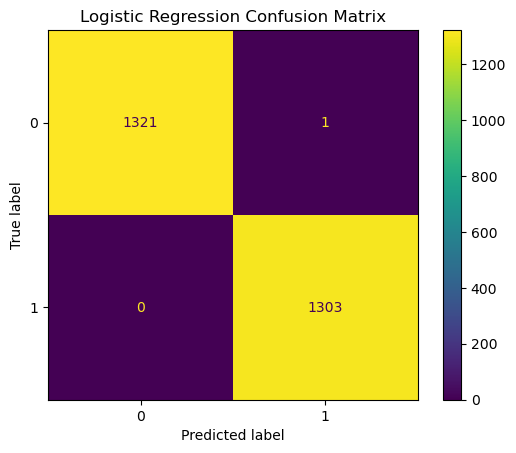

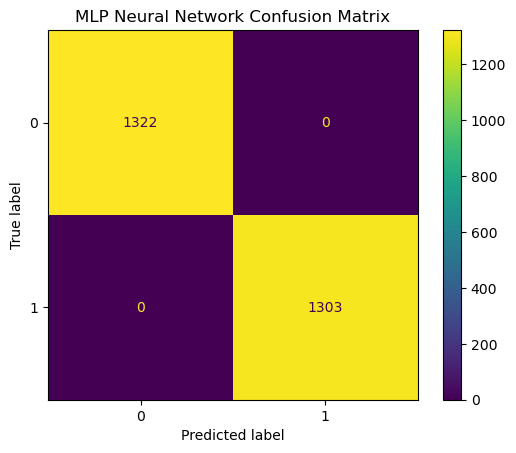

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp)
plt.title("MLP Neural Network Confusion Matrix")
plt.show()

## 13. ROC Curve Comparison

<Figure size 800x600 with 0 Axes>

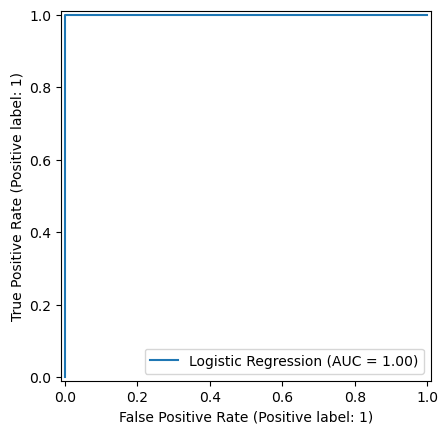

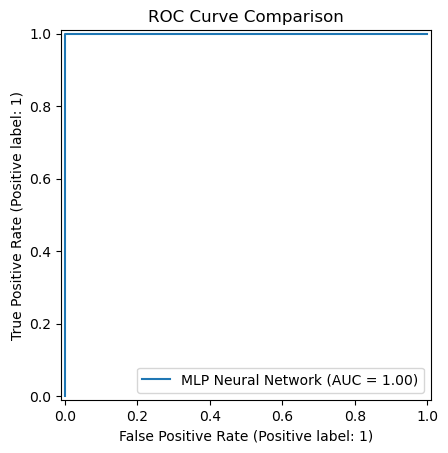

In [13]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_mlp, name="MLP Neural Network")
plt.title("ROC Curve Comparison")
plt.show()

## 14. Save Results

In [14]:
comparison_df.to_csv("model_comparison_results.csv", index=False)
print("Saved model comparison results to model_comparison_results.csv")

Saved model comparison results to model_comparison_results.csv
